# Generative Model for SVHN Image and Label Synthesis Evaluation

This notebook will be used for evaluationg your model. Your task is to complete the model definition and generator function cell. You need to copy over you model definition, load the weights, and make sure that the generator function is generating the data in the correct format.

The generator models are evaluated by training a fixed classifier on their generated data, and measuring the classifier performance on an evaluation dataset. You **CANNOT** modify the classifier or its training. The classifier is trained with 3 seeds. The 3 seeds are going to be changed for the final evaluation and the leaderboard to avoid overfitting to these seeds.



## Tasks:
   - Define a class for your generative model.
   - Load the weights you have trained into this model from your checkpoint.
   - If needed, you can modify the function named `generate` to work with your model.

## Generator function:
You can modify the `generate`, but it should satisfy the the follwing properties.
- **Input:**
   - number of samples

- **Output:**
   - A floating-point image matrix of size `(n_samples x 3 x 32 x 32)` in the range of [0,1].
   - An integer label matrix of size `(n_samples x 1)` in the range of 0 to 9.

- **Perfomrance constraint:**
   - Ensure the generation of 1000 samples within 3 seconds on the snowflake cluster or colab.
   - Stay within a maximum of 10GB of GPU memory.

## Important

- **Fixed classifier:**  You can only modify the model definition and generator function cell.
- **Data:**  Do not load any external data.
- **Models:**  Do not load externaly pre-trained (not by you for this hackathon) models.



Follow the provided structure, and make sure to comply with the outlined requirements. The success of your submission depends on the effectiveness of your generator function and the ability of your model to produce realistic SVHN images with accurate labels. Highest classifier accuracy wins.

Submission instructions in the main notebook.


In [9]:
team_members = ['Gian','Olle']
assert len(team_members) > 0

### Imports

In [10]:
import os
import time
import numpy as np
from tqdm import tqdm
from google.colab import drive
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from sklearn.metrics import accuracy_score

import torch
import torch.nn as nn
from torch.optim import Adam
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import SVHN
import torchvision.transforms as transforms
from torchvision.utils import save_image, make_grid

In [11]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [12]:
device = torch.device('cuda')
print(device)

cuda


In [13]:
import os

latest_checkpoint = '/content/gdrive/My Drive/Hackaton/checkpoint_epoch_20.pth'
if os.path.exists(latest_checkpoint):
    print("Checkpoint file found:", latest_checkpoint)
else:
    print("Checkpoint file not found. Check the path and ensure Google Drive is mounted correctly.")


Checkpoint file found: /content/gdrive/My Drive/Hackaton/checkpoint_epoch_20.pth


In [14]:
class VAE(nn.Module):
    def __init__(self, image_channels=3, h_dim=1024, z_dim=16):
        super(VAE, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(image_channels, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64*8*8, h_dim),
            nn.ReLU(),
        )

        self.fc1 = nn.Linear(h_dim, z_dim)
        self.fc2 = nn.Linear(h_dim, z_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, 64*8*8),
            nn.ReLU(),
            nn.Unflatten(1, (64, 8, 8)),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, image_channels, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        h = self.encoder(x)
        mu, log_var = self.fc1(h), self.fc2(h)
        z = self.reparameterize(mu, log_var)
        return self.decoder(z), mu, log_var


In [ ]:
print(device)

cuda


In [15]:
import torch

# Define the model and optimizer
# Assuming `model` and `optimizer` are already defined with the same structure as used during saving
# For example:

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


# Load the checkpoint
checkpoint = torch.load(latest_checkpoint, map_location=torch.device('cuda'))  # Add map_location if needed

# Load model and optimizer states
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# Load additional checkpoint information
epoch = checkpoint['epoch']
loss = checkpoint['loss']
print(f"Checkpoint loaded. Model was at epoch {epoch} with loss {loss}.")

Checkpoint loaded. Model was at epoch 20 with loss 2.


### Model definition and generator function

You can modify this cell. Complete the generate function to sample data from your model output.

In [38]:
'''
So this code was the one we tried to optimize. We wanted use the latent vectors (that where trained in the VAE model), and use this to generate
new images. This means we would for example take a 3 and and then we sample latent spaces of different trained 3's and then we can add some noise for example. Here
we tried to use a gaussian distribution that was fit to the mean and variance of the latent vector. Then we use this in the decoder to generate the image. 

This also didnt work well. The model we used here gave the best output. We think here simplicity is good, because our decoder is already not very good. If 
we would average latent spaces and add noise etc. , we wont be able to reconstruct anything good, as the latent spaces are too complex...

# Generator class with Gaussian sampling for label-specific generation
class Generator(nn.Module):
    def __init__(self, decoder, latent_vectors_dict, z_dim=16, n_classes=10):
        super(Generator, self).__init__()
        self.decoder = decoder
        self.z_dim = z_dim
        self.n_classes = n_classes
        self.latent_vectors_dict = latent_vectors_dict  # Dictionary of latent vectors mapped by label

    def generate(self, n_samples, device='cuda', target_label=None, noise_scale=0.001):
        with torch.no_grad():
            if target_label is not None and target_label not in self.latent_vectors_dict:
                raise ValueError(f"No latent vectors found for the label: {target_label}")

            if target_label:
                # Get latent vectors for the specified label
                latent_vectors = self.latent_vectors_dict[target_label]

                # Fit a Gaussian distribution to the latent vectors
                latent_mean = latent_vectors.mean(dim=0)  # Mean of the latent vectors
                latent_std = latent_vectors.std(dim=0)  # Standard deviation of the latent vectors

                # Create a Gaussian distribution with the calculated mean and standard deviation
                gaussian_distribution = dist.Normal(latent_mean, latent_std * noise_scale)

                # Sample from the Gaussian distribution to create new latent samples
                latent_samples = gaussian_distribution.sample((n_samples,))

            else:
                # Generate random latent vectors if no specific label is provided
                latent_samples = torch.randn(n_samples, self.z_dim, device=device)

            # Decode the latent samples to generate new images
            generated_images = self.decoder(latent_samples)

            # Generate corresponding labels
            if target_label:
                labels = torch.full((n_samples,), target_label, device=device)
            else:
                labels = torch.randint(0, self.n_classes, (n_samples,), device=device)

        return generated_images, labels


# Generator function to return generated images and labels
def generate(n_samples=None, device='cuda', target_label=None, noise_scale=0.1):
    if n_samples is None:
        n_samples = 1000  # Default number of samples

    generator_model.eval()  # Ensure the generator is in evaluation mode
    images, labels = generator_model.generate(n_samples, device, target_label, noise_scale)
    return images, labels


# Generator function to return generated images and labels
def generate(n_samples=None, device='cuda', target_label=None, noise_scale=0.1):
    if n_samples is None:
        n_samples = 1000  # Default number of samples

    generator_model.eval()  # Ensure the generator is in evaluation mode
    images, labels = generator_model.generate(n_samples, device, target_label, noise_scale)
    return images, labels        
    '''

class Generator(nn.Module):
    def __init__(self, decoder, z_dim=16, n_classes=10):
        super(Generator, self).__init__()
        self.decoder = decoder
        self.z_dim = z_dim
        self.n_classes = n_classes

    def generate(self, n_samples, device='cuda'):
        # Generate random latent vectors
        latent_vectors = torch.randn(n_samples, self.z_dim).to(device)

        # Generate random labels
        labels = torch.randint(0, self.n_classes, (n_samples,)).to(device)

        # Decode the latent vectors to generate new images
        with torch.no_grad():
            generated_images = self.decoder(latent_vectors)

        return generated_images, labels

# Assuming model is an instance of the trained VAE model and decoder is the decoder part of the VAE
decoder = model.decoder
generator_model = Generator(decoder).to(device)

def generate(n_samples=None, device='cuda'):
    if n_samples is None:
        n_samples = 1000  # Default number of samples

    generator_model.eval()
    images, labels = generator_model.generate(n_samples, device=device)
    return images, labels

In [39]:
num_samples = 50
images, labels = generate(num_samples, device=device)



### Speed test

Testing if your model can sample at the required speed. If you are over the limit, then please simplify your model.

In [40]:
num_runs = 10

start_time = time.time()
for _ in range(num_runs):
    generate(n_samples=1000)
end_time = time.time()

average_time = (end_time - start_time) / num_runs
print(f"Average time per execution: {average_time:.6f} seconds")
if device == "cpu":
    print("Running on the CPU can make generating samples slower")
assert average_time <= 3, "Your generator is too slow (takes more than 3s to generate 1000 samples)"

Average time per execution: 0.007262 seconds


### Visualizing samples from your model

In [41]:
reconstructed_images = images
print(reconstructed_images.shape)

torch.Size([50, 3, 32, 32])


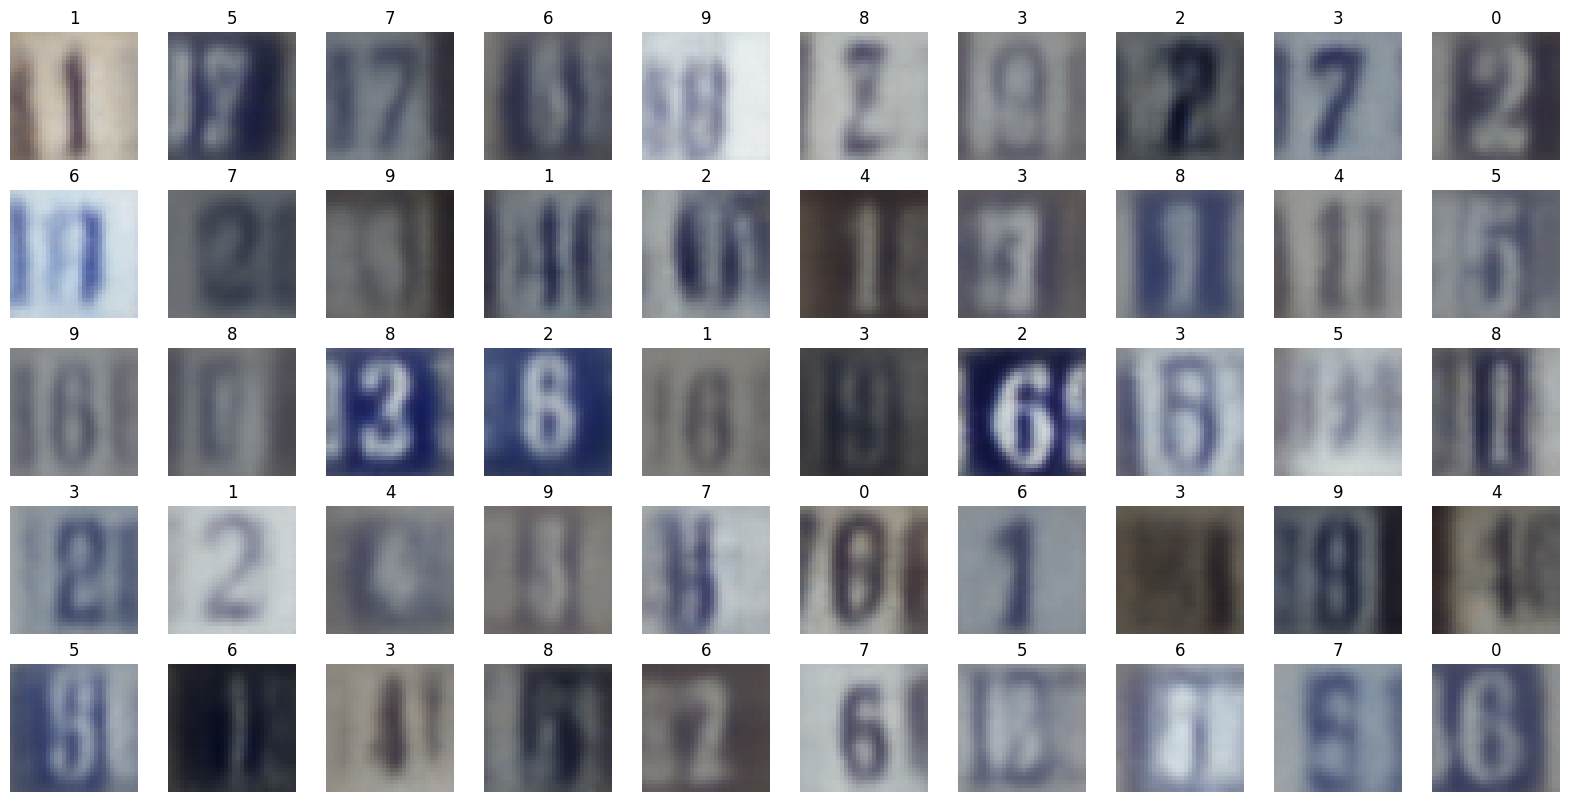

In [42]:
# Assuming 'reconstructed_images' is a tensor of shape (50, 3, 32, 32)
fig = plt.figure(figsize=(20, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(5, 10), axes_pad=0.3)

for ax, im, label in zip(grid, reconstructed_images, labels):
    # Move the image to CPU and convert it to a numpy array
    im = im.detach().cpu().numpy()

    # Transpose the image from (3, 32, 32) to (32, 32, 3)
    im = np.transpose(im, (1, 2, 0))

    ax.imshow(im)
    ax.axis('off')
    ax.set_title(f'{label.item()}')

plt.show()




## Classifier - DO **NOT** MODIFY ANY OF THESE CELLS

### Classifier definition

In [32]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()

        # Convolutional layers
        self.conv_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(3, 32, kernel_size=(3, 3), padding=(1, 1)),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.Dropout2d(p=0.0),
                nn.MaxPool2d(kernel_size=(2, 2))
            ),
            nn.Sequential(
                nn.Conv2d(32, 64, kernel_size=(3, 3), padding=(1, 1)),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Dropout2d(p=0.0),
                nn.MaxPool2d(kernel_size=(2, 2))
            ),
            nn.Sequential(
                nn.Conv2d(64, 64, kernel_size=(3, 3), padding=(1, 1)),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.Dropout2d(p=0.0),
                nn.MaxPool2d(kernel_size=(2, 2))
            )
        ])

        # Flatten
        self.flatten = nn.Flatten()

        # Linear layers
        self.linear_blocks = nn.ModuleList([
            nn.Sequential(
                nn.Linear(64 * 4 * 4, 64),
                nn.Dropout(p=0.0),
                nn.ReLU()
            ),
            nn.Sequential(
                nn.Linear(64, 10),
                nn.Dropout(p=0.0),
                nn.LogSoftmax(dim=1)
            )
        ])

    def forward(self, x):
        for conv_block in self.conv_blocks:
            x = conv_block(x)
        x = self.flatten(x)
        for linear_block in self.linear_blocks:
            x = linear_block(x)
        return x

### Training and evaluation functions

In [43]:
def train_one_epoch(classifier, optimizer, loss_fn, num_iters=100):
    classifier.train()
    train_losses_epoch, train_accs_epoch = [], []
    progress_bar = tqdm(range(num_iters), desc='Training')

    for _ in progress_bar:
        images, labels = generate()
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = classifier(images)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        train_losses_epoch.append(loss.item())
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = labels.cpu().numpy()
        train_accs_epoch.append(accuracy_score(preds, labels))

    train_loss_epoch = sum(train_losses_epoch) / len(train_losses_epoch)
    train_acc_epoch = sum(train_accs_epoch) / len(train_accs_epoch)

    return train_loss_epoch, train_acc_epoch

def evaluate(model, test_loader, loss_fn):
    model.eval()
    true_values, pred_values = [], []
    losses = []
    for batch in test_loader:
        images, labels = batch
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            logits = model(images)
            loss = loss_fn(logits, labels)
        losses.append(loss.item())
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        labels = labels.cpu().numpy()

        true_values.extend(labels.tolist())
        pred_values.extend(preds.tolist())

    accuracy = accuracy_score(pred_values, true_values)
    loss = sum(losses) / len(losses)
    return true_values, pred_values, loss, accuracy

def plot_training_curves(train_losses, train_accs, val_losses, val_accs):
    plt.subplot(2, 1, 1)
    plt.plot(np.arange(len(train_losses))+1, train_losses, label="train")
    plt.plot(np.arange(len(val_losses))+1, val_losses, label="valid")
    plt.xlabel("epochs")
    plt.ylabel("loss")
    plt.legend(loc="best")

    plt.subplot(2, 1, 2)
    plt.plot(np.arange(len(train_accs))+1, train_accs, label="train")
    plt.plot(np.arange(len(val_accs))+1, val_accs, label="valid")
    plt.xlabel("epochs")
    plt.ylabel("accuracy")
    plt.legend(loc="best")

    plt.tight_layout()
    plt.show()

### Running training and evaluation with 3 seeds

Using downloaded and verified file: /root/datasets/test_32x32.mat


Training: 100%|██████████| 100/100 [00:05<00:00, 17.31it/s]


Epoch  1 | Train Loss: 2.305, Accuracy: 10.08% | Validation Loss: 2.307, Accuracy: 8.59%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.60it/s]


Epoch  2 | Train Loss: 2.303, Accuracy: 9.82% | Validation Loss: 2.310, Accuracy: 7.77%


...

Epoch  8 | Train Loss: 2.303, Accuracy: 10.01% | Validation Loss: 2.305, Accuracy: 7.38%


Training: 100%|██████████| 100/100 [00:04<00:00, 21.92it/s]


Epoch  9 | Train Loss: 2.303, Accuracy: 10.02% | Validation Loss: 2.298, Accuracy: 18.97%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.41it/s]


Epoch 10 | Train Loss: 2.303, Accuracy: 10.06% | Validation Loss: 2.303, Accuracy: 12.33%


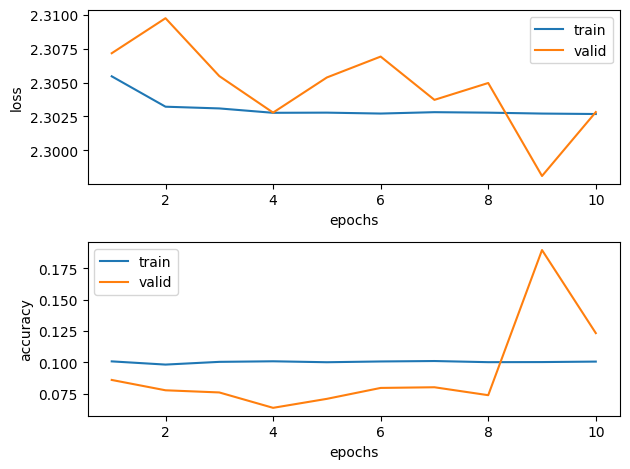

Training: 100%|██████████| 100/100 [00:04<00:00, 22.63it/s]


Epoch  1 | Train Loss: 2.305, Accuracy: 10.29% | Validation Loss: 2.300, Accuracy: 9.69%


Training: 100%|██████████| 100/100 [00:04<00:00, 20.57it/s]


Epoch  2 | Train Loss: 2.303, Accuracy: 9.95% | Validation Loss: 2.301, Accuracy: 9.69%


Training: 100%|██████████| 100/100 [00:04<00:00, 23.00it/s]


...

Epoch  8 | Train Loss: 2.303, Accuracy: 9.97% | Validation Loss: 2.301, Accuracy: 15.94%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.88it/s]


Epoch  9 | Train Loss: 2.303, Accuracy: 9.95% | Validation Loss: 2.302, Accuracy: 15.94%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.81it/s]


Epoch 10 | Train Loss: 2.303, Accuracy: 9.97% | Validation Loss: 2.301, Accuracy: 7.59%


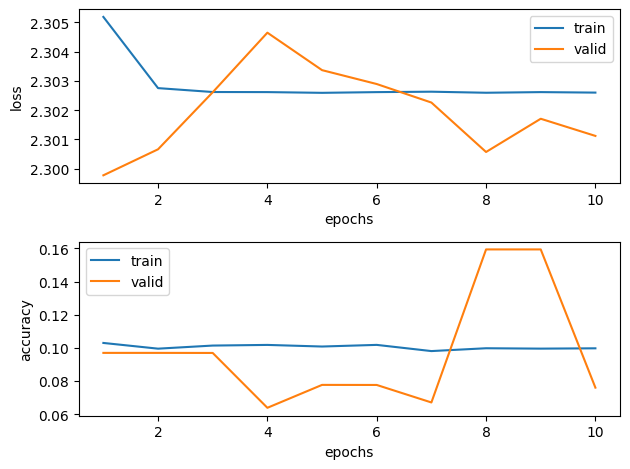

Training: 100%|██████████| 100/100 [00:04<00:00, 22.13it/s]


Epoch  1 | Train Loss: 2.306, Accuracy: 10.05% | Validation Loss: 2.305, Accuracy: 9.57%


Training: 100%|██████████| 100/100 [00:04<00:00, 21.98it/s]


Epoch  2 | Train Loss: 2.303, Accuracy: 9.95% | Validation Loss: 2.301, Accuracy: 9.17%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.38it/s]


...

Epoch  8 | Train Loss: 2.303, Accuracy: 10.03% | Validation Loss: 2.303, Accuracy: 10.34%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.27it/s]


Epoch  9 | Train Loss: 2.303, Accuracy: 10.04% | Validation Loss: 2.303, Accuracy: 9.16%


Training: 100%|██████████| 100/100 [00:04<00:00, 22.23it/s]


Epoch 10 | Train Loss: 2.303, Accuracy: 9.83% | Validation Loss: 2.302, Accuracy: 9.63%


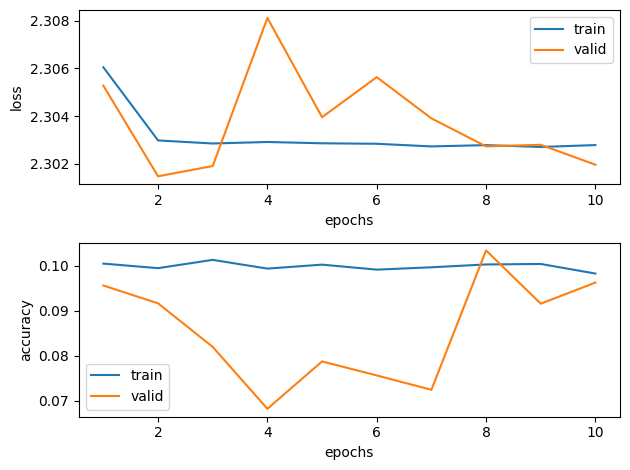

Final score: validation accuracy over 3 seeds| mean: 9.8533% | std: 1.9416%


In [44]:
transform = transforms.ToTensor()
test_dataset = SVHN(root='~/datasets', split='test', transform=transform, download=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

def run_experiment(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    classifier = Classifier().to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(classifier.parameters(), lr=0.001)

    NUM_EPOCHS = 10
    train_losses, train_accs, val_losses, val_accs = [], [], [], []
    for epoch in range(1, NUM_EPOCHS + 1):
        # Training
        train_loss_epoch, train_acc_epoch = train_one_epoch(classifier, optimizer, loss_fn)

        # Validation
        true_values, pred_values, val_loss_epoch, val_acc_epoch = evaluate(classifier, test_loader, loss_fn)

        print(f"Epoch {epoch:2d} | Train Loss: {train_loss_epoch:.3f}, Accuracy: {train_acc_epoch * 100:.2f}% | Validation Loss: {val_loss_epoch:.3f}, Accuracy: {val_acc_epoch * 100:.2f}%")
        train_losses.append(train_loss_epoch)
        train_accs.append(train_acc_epoch)
        val_losses.append(val_loss_epoch)
        val_accs.append(val_acc_epoch)

    plot_training_curves(train_losses, train_accs, val_losses, val_accs)
    return val_accs[-1]

num_seeds = 3
val_accuracies = [run_experiment(seed) for seed in range(num_seeds)]
print(f"Final score: validation accuracy over {num_seeds} seeds| mean: {np.mean(val_accuracies) * 100:.4f}% | std: {np.std(val_accuracies) * 100:.4f}%")